# 06. Maintenance economics: thresholds set by value, not accuracy

An alert is only worth something if it arrives early enough to act on, **including getting the spare part in**:

```
lead ≥ L_parts + L_schedule      → value = C_unplanned − C_planned
0 < lead < L_parts + L_schedule  → value = C_unplanned − C_planned − C_expedite
missed / not before onset        → value = 0
net value = Σ value(caught failures) − false alerts × C_inspection
```

All costs are in `config/costs.yaml` and are **illustrative assumptions**, to be replaced with a plant's own figures. Here we:
1. sweep the alert threshold of each Module A detector and find the value-maximising operating point,
2. compute the **break-even false-alarm rate**,
3. test how the optimum shifts when parts take 1 day vs 2 weeks,
4. do the same for the Module B onset threshold *k*.

> **Caveat:** with 4 failures per module, every "optimal" threshold below is chosen in-sample. Read the curves for their *shape* (how forgiving the operating range is, how lead time changes it), not the exact optimum.

In [1]:
import sys
import warnings
from pathlib import Path

# Make `src/` importable whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from compressor_guard.config import FIGURES_DIR, load_params

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
params = load_params()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FAIL_COLOR, ALERT_COLOR, FROZEN_COLOR = "#d62728", "#ff7f0e", "#7f7f7f"

import json
from compressor_guard.backtest import sweep_thresholds
from compressor_guard.data import load_failures
from compressor_guard.economics import CostModel, parts_lead_scenarios
from compressor_guard.models import training_mask
from compressor_guard.alerts import smooth_anomaly_scores
from compressor_guard.features import load_features_parquet
from compressor_guard.vibration.health import evaluate_onsets, summarise_test

cm = CostModel.from_yaml(ROOT / "config/costs.yaml")
scen_hours = parts_lead_scenarios(ROOT / "config/costs.yaml")
scenarios = {f"parts {h:g} h": cm.with_parts_lead(h) for h in scen_hours}
failures = load_failures(ROOT / "config/failures.yaml")
display(pd.Series(cm.__dict__, name="value").to_frame())
print(f"Full-value warning needs ≥ {cm.required_lead_hours:g} h lead: saves ${cm.full_value:,.0f}; "
      f"a late (expedited) warning saves ${cm.expedited_value:,.0f}; each false alert costs ${cm.false_inspection:,.0f}")

,value
unplanned_failure,25000.0
planned_maintenance,4000.0
expedite_penalty,5000.0
false_inspection,500.0
parts_delivery_hours,48.0
scheduling_hours,12.0


Full-value warning needs ≥ 60 h lead: saves $21,000; a late (expedited) warning saves $16,000; each false alert costs $500


## 1. Module A: threshold sweep

To put the three detectors on one axis, each threshold is expressed as a **quantile of that detector's smoothed score on healthy training data**. For example, 0.995 means that 0.5 % of healthy minutes sit above the threshold. The defaults from notebook 03 are 0.995 for IF/LSTM and 3σ for control limits.

In [2]:
feats = load_features_parquet(ROOT / params["metropt"]["processed_parquet_path"])
scores = pd.read_parquet(ROOT / params["metropt"]["scores_parquet_path"])
thresholds = json.loads((ROOT / params["metropt"]["model_dir"] / "thresholds.json").read_text())
train = training_mask(feats, params).to_numpy()
MODELS = ["control_limits", "isolation_forest", "lstm_autoencoder"]
LABELS = {"control_limits": "±3σ control limits", "isolation_forest": "Isolation Forest",
          "lstm_autoencoder": "LSTM autoencoder"}
QUANTILES = [0.95, 0.97, 0.98, 0.99, 0.993, 0.995, 0.997, 0.998, 0.999, 0.9995, 0.9999]

sweeps = []
for n in MODELS:
    sm = smooth_anomaly_scores(scores[f"score_{n}"].to_numpy(), params["metropt"]["alert_logic"]["smoothing_window_minutes"],
                               timestamps=scores["timestamp"])[train]
    ths = np.quantile(sm, QUANTILES)
    sw = sweep_thresholds(scores, f"score_{n}", ths, params, cost_models=scenarios, failures=failures)
    sw["quantile"] = np.repeat(QUANTILES, len(scenarios))
    sw["model"] = LABELS[n]
    sweeps.append(sw)
    default_q = float((sm <= thresholds[n]).mean())
    print(f"{LABELS[n]:20s} default threshold ≈ healthy quantile {default_q:.4f}")
sweeps = pd.concat(sweeps, ignore_index=True)
base = f"parts {cm.parts_delivery_hours:g} h"
display(sweeps[sweeps["scenario"] == base].pivot(index="quantile", columns="model", values="net_value").round(0))

±3σ control limits   default threshold ≈ healthy quantile 0.9422
Isolation Forest     default threshold ≈ healthy quantile 0.9950
LSTM autoencoder     default threshold ≈ healthy quantile 0.9950


model,Isolation Forest,LSTM autoencoder,±3σ control limits
quantile,,,
0.9500,17500.0,22500.0,21000.0
0.9700,24000.0,24000.0,27000.0
0.9800,14000.0,26000.0,27000.0
0.9900,6000.0,27500.0,13500.0
0.9930,10500.0,12000.0,13500.0
0.9950,12000.0,13000.0,14000.0
0.9970,13500.0,14000.0,14000.0
0.9980,13500.0,14000.0,14500.0
0.9990,14000.0,14000.0,-1500.0


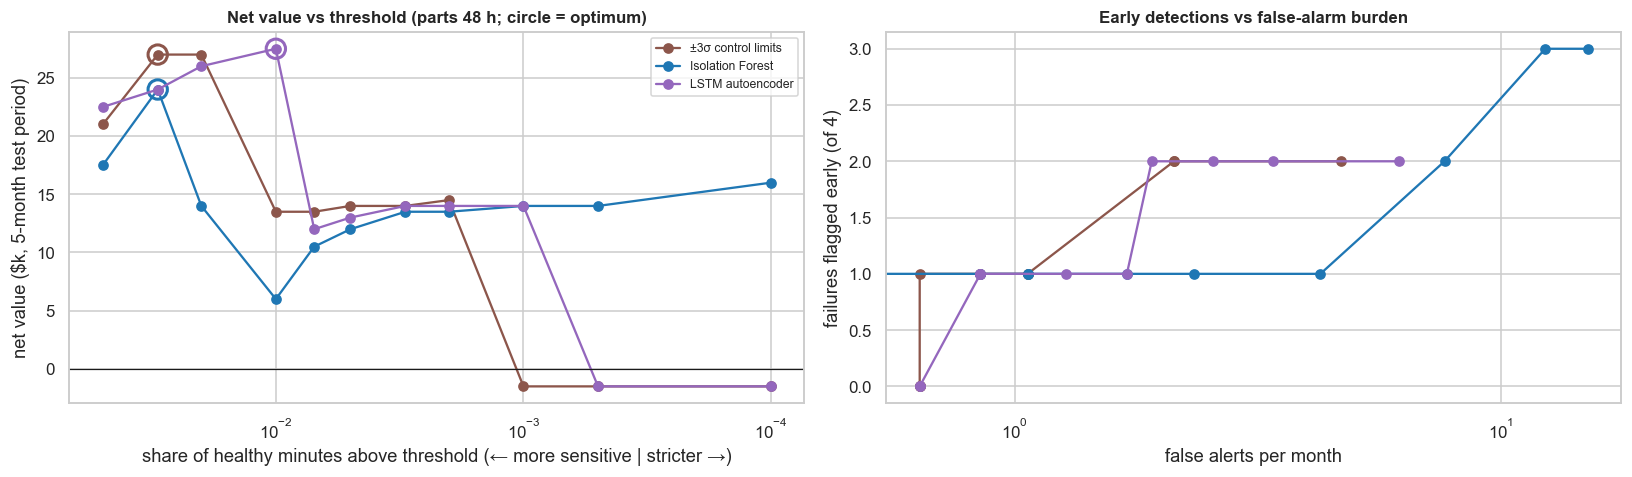

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
b = sweeps[sweeps["scenario"] == base]
for n, c in zip(MODELS, ["#8c564b", "#1f77b4", "#9467bd"]):
    d = b[b["model"] == LABELS[n]]
    axes[0].plot(1 - d["quantile"], d["net_value"] / 1000, marker="o", color=c, label=LABELS[n])
    best = d.loc[d["net_value"].idxmax()]
    axes[0].scatter(1 - best["quantile"], best["net_value"] / 1000, s=160, facecolors="none", edgecolors=c, lw=2)
    axes[1].plot(d["false_alerts_per_month"], d["flagged_early"], marker="o", color=c, label=LABELS[n])
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xscale("log"); axes[0].invert_xaxis()
axes[0].set(xlabel="share of healthy minutes above threshold (← more sensitive | stricter →)",
            ylabel="net value ($k, 5-month test period)", title=f"Net value vs threshold ({base}; circle = optimum)")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="false alerts per month", ylabel="failures flagged early (of 4)",
            title="Early detections vs false-alarm burden")
axes[1].set_xscale("log")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "economics_net_value.png")
plt.show()

## 2. Operating points & break-even false-alarm rate

The break-even rate is how many false alerts per month the programme could absorb, **given the failures it catches at that threshold**, before the net value falls to zero.

In [4]:
rows = []
for n in MODELS:
    d = sweeps[(sweeps["scenario"] == base) & (sweeps["model"] == LABELS[n])]
    best = d.loc[d["net_value"].idxmax()]
    rows.append({"model": LABELS[n], "best_quantile": best["quantile"], "flagged_early": int(best["flagged_early"]),
                 "median_lead_h": round(best["median_lead_h"], 1), "false_alerts_per_month": round(best["false_alerts_per_month"], 2),
                 "break_even_FA_per_month": round(best["break_even_false_alerts_per_month"], 1),
                 "net_value_usd": round(best["net_value"])})
op = pd.DataFrame(rows)
op.to_csv(ROOT / "reports/economics_operating_points.csv", index=False)
display(op)

,model,best_quantile,flagged_early,median_lead_h,false_alerts_per_month,break_even_FA_per_month,net_value_usd
0,±3σ control limits,0.97,2,50.5,2.13,13.6,27000
1,Isolation Forest,0.97,3,46.8,12.33,22.5,24000
2,LSTM autoencoder,0.99,2,40.9,1.91,13.6,27500


## 3. Sensitivity to spare-part lead time

Longer parts lead times make early warnings more valuable. Each caught failure moves from "expedited" to "full" value only if the lead time covers parts + scheduling. With few early detections here, the lead-time effect mostly shows as *less value per catch*.

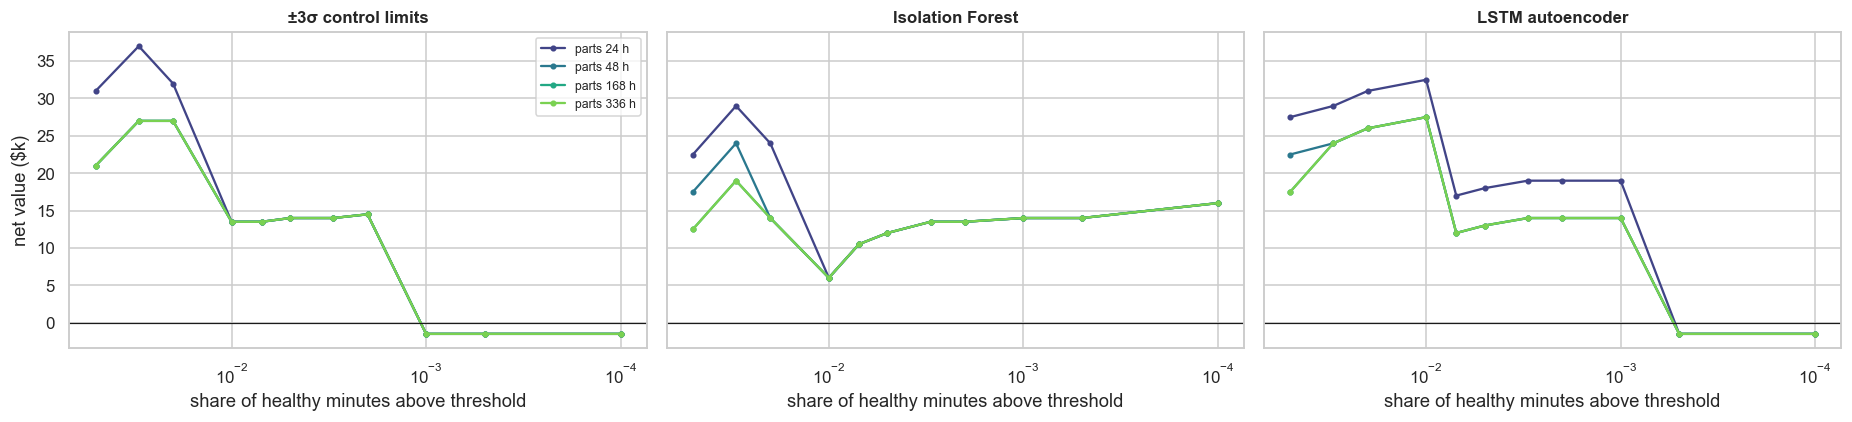

best_quantile                                        net_value_usd                                    
model       Isolation Forest LSTM autoencoder ±3σ control limits Isolation Forest LSTM autoencoder ±3σ control limits
scenario                                                                                                             
parts 168 h             0.97             0.99               0.97          19000.0          27500.0            27000.0
parts 24 h              0.97             0.99               0.97          29000.0          32500.0            37000.0
parts 336 h             0.97             0.99               0.97          19000.0          27500.0            27000.0
parts 48 h              0.97             0.99               0.97          24000.0          27500.0            27000.0

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
rows = []
for ax, n in zip(axes, MODELS):
    for sc, c in zip(scenarios, sns.color_palette("viridis", len(scenarios))):
        d = sweeps[(sweeps["scenario"] == sc) & (sweeps["model"] == LABELS[n])]
        ax.plot(1 - d["quantile"], d["net_value"] / 1000, marker=".", color=c, label=sc)
        best = d.loc[d["net_value"].idxmax()]
        rows.append({"model": LABELS[n], "scenario": sc, "best_quantile": best["quantile"],
                     "net_value_usd": round(best["net_value"]), "flagged_early": int(best["flagged_early"])})
    ax.axhline(0, color="k", lw=0.8); ax.set_xscale("log"); ax.invert_xaxis()
    ax.set(title=LABELS[n], xlabel="share of healthy minutes above threshold")
axes[0].set_ylabel("net value ($k)"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).pivot(index="scenario", columns="model", values=["best_quantile", "net_value_usd"]))

## 4. Module B: onset threshold *k*

Each failed bearing detected with lead time *T* (≤ 1 week) is valued with the same cost model. Each false alarm (an alarm on a failing bearing more than a week early, or on a surviving bearing before its rig's real onset) costs one inspection.

,k,detected,median_lead_h,false_alarms,net_value
1,4,3,77.8,36,45000.0
5,6,4,75.4,21,68500.0
9,8,4,74.3,17,70500.0
13,10,4,73.0,17,70500.0
17,12,4,70.9,11,73500.0
21,15,4,65.0,1,73500.0
25,20,4,61.6,1,73500.0
29,25,4,55.5,1,73500.0
33,30,3,44.2,1,52500.0


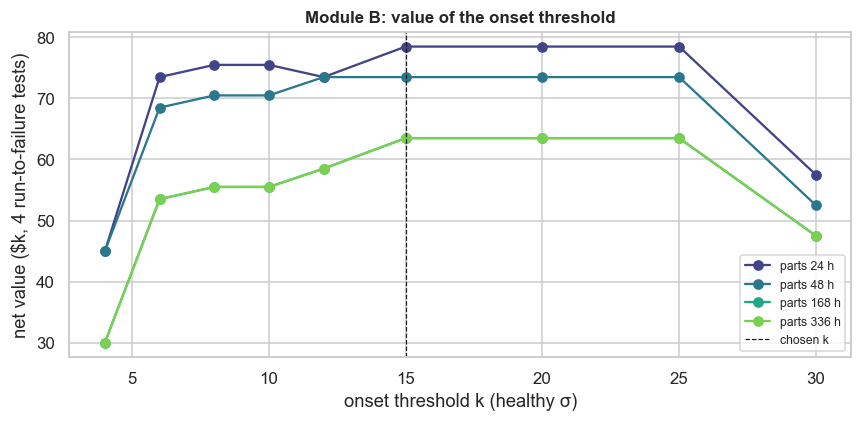

In [6]:
hi = pd.read_parquet(ROOT / params["ims"]["processed_dir"] / "ims_health.parquet")
pers = params["ims"]["health"]["onset_persistence"]
rows = []
for k in (4, 6, 8, 10, 12, 15, 20, 25, 30):
    e = evaluate_onsets(summarise_test(hi, k, pers, params["ims"]["health"]["max_lead_hours"]))
    for sc, m in scenarios.items():
        rows.append({"k": k, "scenario": sc, "detected": e["detected"], "median_lead_h": e["median_lead_hours"],
                     "false_alarms": e["false_alarms"], "net_value": m.net_value(e["lead_hours"], e["false_alarms"])})
bsw = pd.DataFrame(rows)
display(bsw[bsw["scenario"] == base].drop(columns="scenario").round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for sc, c in zip(scenarios, sns.color_palette("viridis", len(scenarios))):
    d = bsw[bsw["scenario"] == sc]
    ax.plot(d["k"], d["net_value"] / 1000, marker="o", color=c, label=sc)
ax.axvline(params["ims"]["health"]["onset_k"], color="k", ls="--", lw=0.8, label="chosen k")
ax.set(xlabel="onset threshold k (healthy σ)", ylabel="net value ($k, 4 run-to-failure tests)",
       title="Module B: value of the onset threshold")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "economics_module_b.png")
plt.show()

## 5. Takeaways

- **Module A: sensitivity pays, up to a point.** All three detectors reach their best net value at *more sensitive* thresholds than their statistical defaults: roughly the healthy 0.97–0.99 quantile instead of 0.995 (or 3σ). That lifts net value from ~$12–17.5k to ~$24–27.5k over the 5-month test, by catching F3 and/or F4 early. Push further and false-alarm costs take over. Go stricter and the few early catches disappear, and value collapses toward zero. The curves are jagged, because one extra early catch is worth 40 inspections.
- **Break-even:** at the optimum, the detectors could absorb ~14–22 false alerts per month before the programme stops paying, against ~2 (LSTM-AE, control limits) and ~12 (Isolation Forest) actually raised. There is margin, but it rests on 2–3 early catches out of 4 failures.
- **Parts lead time does not move the optimal threshold here, only the value.** No warning in this dataset exceeds ~2.5 days, so with 1–2-week parts every catch drops to the "expedited" value (~$19–27.5k vs ~$29–37k with 1-day parts). For long-lead spares, the answer is to **stock them**. Prediction alone cannot cover a lead time that the failure mode's precursors don't span.
- **Module B:** at the chosen k = 15, bearing alarms arrive 25–118 h ahead (2 of 4 beyond the 60 h needed for full value). Net value is flat from k ≈ 12 to 25. Lower k pays for a flapping healthy bearing (11–36 false inspections), and k ≥ 30 misses a failure.
- **For a real plant:** replace `config/costs.yaml` with actual downtime cost, part lead times and inspection cost, and re-run this notebook. The code path is the same.